<a href="https://colab.research.google.com/github/simsim-px/Praktikum-Fisika/blob/main/TETESAN_MINYAK_MILIKAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   EKSPERIMEN TETES MINYAK MILLIKAN
   Fisika Laboratorium II — ITS Surabaya
   Data: Guidebook Dummy (Tabel 3)

📋 DATA HASIL PENGAMATAN
-----------------------------------------------------------------
 No |      d (m) | t_down (s) | U_r (V) | t_up (s) | U_s (V)
-----------------------------------------------------------------
  1 |   1.00e-03 |      15.42 |   500.0 |     8.21 |   310.0
  2 |   1.00e-03 |      15.38 |   500.0 |     3.45 |   154.0
  3 |   1.00e-03 |      22.10 |   500.0 |    10.15 |   240.0
  4 |   1.00e-03 |      22.15 |   500.0 |     4.12 |   121.0
  5 |   1.00e-03 |      11.05 |   400.0 |    12.50 |   380.0
  6 |   1.00e-03 |      11.10 |   400.0 |     5.10 |   192.0
  7 |   1.00e-03 |      11.08 |   400.0 |     3.20 |   128.0
  8 |   1.00e-03 |       9.50 |   450.0 |     9.80 |   410.0
  9 |   1.00e-03 |       9.55 |   450.0 |     4.30 |   205.0
 10 |   1.00e-03 |      18.20 |   500.0 |     7.15 |   280.0
 11 |   1.00e-03 |      18.25 |   500.0 |     3.10 |   139.0

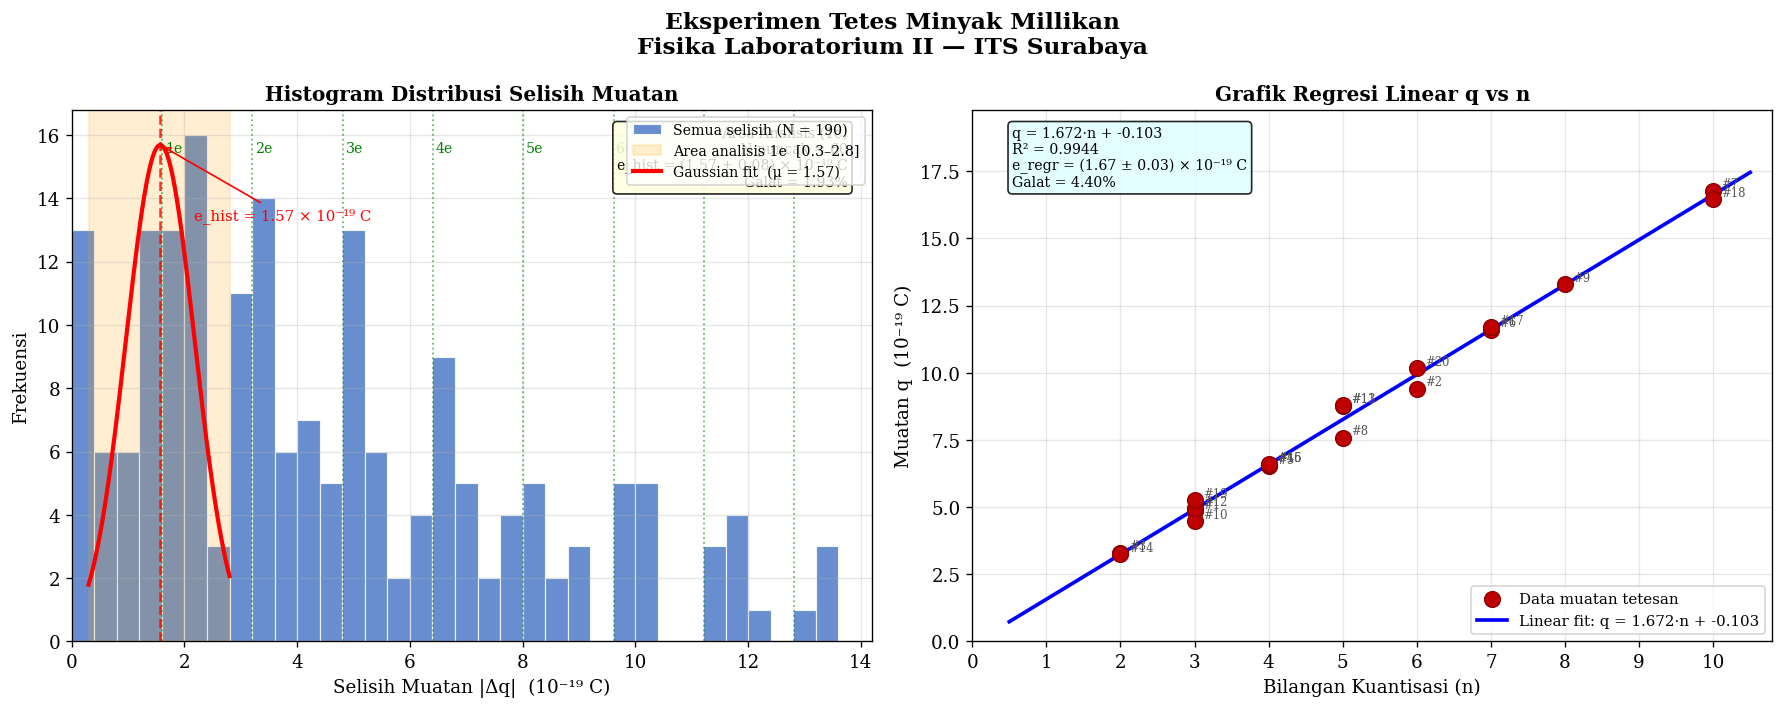


✅  Grafik tersimpan sebagai 'millikan_grafik_guidebook.png'

   TABEL LENGKAP SEMUA PARAMETER TERHITUNG
 No  v_d (×10⁻⁵ m/s)  v_u (×10⁻⁵ m/s)  r (×10⁻⁷ m)  qr (×10⁻¹⁹ C)  qf (×10⁻¹⁹ C)  q_avg (×10⁻¹⁹ C)  n  e_est (×10⁻¹⁹ C)
  1           6.4851          12.1803       7.9366         6.1990         3.4738            4.8364  3            1.6121
  2           6.5020          28.9855       7.9469        11.8012         7.0201            9.4106  6            1.5684
  3           4.5249           9.8522       6.6295         3.9884         2.6152            3.3018  2            1.6509
  4           4.5147          24.2718       6.6220         7.9768         5.1695            6.5732  4            1.6433
  5           9.0498           8.0000       9.3755         8.3613         4.6717            6.5165  4            1.6291
  6           9.0090          19.6078       9.3543        14.0023         9.1836           11.5929  7            1.6561
  7           9.0253          31.2500       9.3628     

In [2]:
"""
=============================================================================
EKSPERIMEN TETES MINYAK MILLIKAN - ANALISIS LENGKAP
Fisika Laboratorium II | ITS Surabaya
=============================================================================
DATA: Data Dummy dari Guidebook (Tabel 3)
Panduan penggunaan:
  1. Copy-paste seluruh kode ini ke Google Colab (File > New Notebook)
  2. Jalankan semua: Runtime > Run All
=============================================================================
"""

# ============================================================
# CELL 1: IMPORT LIBRARY
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print("=" * 65)
print("   EKSPERIMEN TETES MINYAK MILLIKAN")
print("   Fisika Laboratorium II — ITS Surabaya")
print("   Data: Guidebook Dummy (Tabel 3)")
print("=" * 65)


# ============================================================
# CELL 2: INPUT DATA PENGAMATAN
# ============================================================
# Format kolom:
#   No | d (m) | t_down (s) | U_r (V) | t_up (s) | U_s (V)
#
# Catatan: pada data ini U_r (tegangan naik) ada di kolom "Volt (V)"
# di bagian Gerak Naik, dan U_s (stopping voltage) ada di kolom "Volt (Vs)"
# di bagian Floating.

data_raw = [
    # No   t_down   U_r    t_up    U_s
    [ 1,   15.42,   500,   8.21,   310],
    [ 2,   15.38,   500,   3.45,   154],
    [ 3,   22.10,   500,  10.15,   240],
    [ 4,   22.15,   500,   4.12,   121],
    [ 5,   11.05,   400,  12.50,   380],
    [ 6,   11.10,   400,   5.10,   192],
    [ 7,   11.08,   400,   3.20,   128],
    [ 8,    9.50,   450,   9.80,   410],
    [ 9,    9.55,   450,   4.30,   205],
    [10,   18.20,   500,   7.15,   280],
    [11,   18.25,   500,   3.10,   139],
    [12,   13.40,   400,  15.20,   365],
    [13,   13.35,   400,   6.40,   184],
    [14,   25.60,   550,   8.40,   180],
    [15,   25.55,   550,   3.50,    91],
    [16,   10.20,   450,  11.10,   430],
    [17,   10.15,   450,   4.80,   214],
    [18,   10.22,   450,   3.10,   144],
    [19,   16.80,   500,   6.50,   255],
    [20,   16.75,   500,   2.90,   128],
]

df = pd.DataFrame(data_raw, columns=['No', 't_down', 'U_r', 't_up', 'U_s'])
d_jarak = 1.00e-3  # jarak satu skala grid (m), sama untuk semua data

print("\n📋 DATA HASIL PENGAMATAN")
print("-" * 65)
print(f"{'No':>3} | {'d (m)':>10} | {'t_down (s)':>10} | {'U_r (V)':>7} | {'t_up (s)':>8} | {'U_s (V)':>7}")
print("-" * 65)
for _, row in df.iterrows():
    print(f"{int(row['No']):>3} | {d_jarak:>10.2e} | {row['t_down']:>10.2f} | "
          f"{row['U_r']:>7.1f} | {row['t_up']:>8.2f} | {row['U_s']:>7.1f}")
print("-" * 65)


# ============================================================
# CELL 3: KONSTANTA DAN PARAMETER ALAT
# ============================================================
print("\n⚙️  KONSTANTA DAN PARAMETER ALAT")
print("-" * 45)

l       = 6.00e-3    # Jarak antar pelat kapasitor (m)
rho_o   = 875.0      # Massa jenis minyak parafin (kg/m³)
rho_f   = 1.29       # Massa jenis udara @ 25°C (kg/m³)
eta     = 1.85e-5    # Viskositas udara @ 25°C (N·s/m²)
g       = 9.81       # Percepatan gravitasi (m/s²)
e_ref   = 1.602e-19  # Nilai referensi muatan elementer (C)

delta_rho = rho_o - rho_f

print(f"  l     (jarak pelat)   = {l:.2e} m")
print(f"  d     (jarak grid)    = {d_jarak:.2e} m")
print(f"  ρ_o   (minyak parafin)= {rho_o} kg/m³")
print(f"  ρ_f   (udara)         = {rho_f} kg/m³")
print(f"  η     (viskositas)    = {eta:.2e} N·s/m²")
print(f"  g     (gravitasi)     = {g} m/s²")
print(f"  Δρ = ρ_o − ρ_f        = {delta_rho:.2f} kg/m³")


# ============================================================
# CELL 4: FUNGSI PERHITUNGAN
# ============================================================
def kecepatan(t, d=d_jarak):
    return d / t

def jari_jari(v_d):
    return np.sqrt((9 * eta * v_d) / (2 * g * delta_rho))

def muatan_floating(v_d, U_s):
    """qf = (18π η l v_d / U_s) × √(η v_d / 2g Δρ)"""
    return (18 * np.pi * eta * l * v_d / U_s) * np.sqrt((eta * v_d) / (2 * g * delta_rho))

def muatan_rising(v_d, v_u, U_r):
    """qr = (18π η l (v_d+v_u) / U_r) × √(η v_d / 2g Δρ)"""
    return (18 * np.pi * eta * l * (v_d + v_u) / U_r) * np.sqrt((eta * v_d) / (2 * g * delta_rho))

print("\n✅  Fungsi perhitungan siap.")


# ============================================================
# CELL 5: PERHITUNGAN STEP-BY-STEP TIAP TETESAN
# ============================================================
print("\n" + "=" * 65)
print("   PERHITUNGAN STEP-BY-STEP (per tetesan)")
print("=" * 65)

hasil = []

for _, row in df.iterrows():
    no     = int(row['No'])
    t_d    = row['t_down']
    t_u    = row['t_up']
    U_r    = row['U_r']
    U_s    = row['U_s']

    print(f"\n{'─'*60}")
    print(f"  TETESAN No. {no:02d}")
    print(f"  Input : t_down={t_d} s | U_r={U_r} V | t_up={t_u} s | U_s={U_s} V")
    print(f"{'─'*60}")

    # Step 1: Kecepatan terminal
    v_d = kecepatan(t_d)
    v_u = kecepatan(t_u)
    print(f"  [1] Kecepatan Terminal")
    print(f"      v_d = {d_jarak:.2e} / {t_d}  = {v_d:.5e} m/s")
    print(f"      v_u = {d_jarak:.2e} / {t_u}  = {v_u:.5e} m/s")

    # Step 2: Jari-jari
    r = jari_jari(v_d)
    print(f"  [2] Jari-jari Tetesan (Hukum Stokes)")
    print(f"      r = √(9ηv_d / 2gΔρ)")
    print(f"        = √(9×{eta:.2e}×{v_d:.4e} / 2×{g}×{delta_rho:.2f})")
    print(f"        = {r:.5e} m")

    # Step 3: Muatan
    qf    = muatan_floating(v_d, U_s)
    qr    = muatan_rising(v_d, v_u, U_r)
    q_avg = (qf + qr) / 2

    print(f"  [3] Muatan Listrik")
    print(f"      qf  (Floating) = {qf:.5e} C  →  {qf/1e-19:.4f} × 10⁻¹⁹ C")
    print(f"      qr  (Rising)   = {qr:.5e} C  →  {qr/1e-19:.4f} × 10⁻¹⁹ C")
    print(f"      q_avg          = {q_avg:.5e} C  →  {q_avg/1e-19:.4f} × 10⁻¹⁹ C")

    hasil.append({
        'No'   : no,
        't_down': t_d, 't_up': t_u, 'U_r': U_r, 'U_s': U_s,
        'v_d'  : v_d, 'v_u': v_u,
        'r'    : r,
        'qf'   : qf, 'qr': qr, 'q_avg': q_avg,
    })

df_h = pd.DataFrame(hasil)


# ============================================================
# CELL 6: BILANGAN KUANTISASI & TABEL REKAPITULASI
# ============================================================
print("\n" + "=" * 65)
print("   BILANGAN KUANTISASI (n) DAN TABEL REKAPITULASI")
print("=" * 65)

# Estimasi awal e untuk menentukan n
e_est0 = 1.6e-19
df_h['n']     = np.round(df_h['q_avg'] / e_est0).astype(int).clip(lower=1)
df_h['e_est'] = df_h['q_avg'] / df_h['n']

print(f"\n{'No':>3} | {'qr (×10⁻¹⁹)':>12} | {'qf (×10⁻¹⁹)':>12} | "
      f"{'qavg (×10⁻¹⁹)':>14} | {'n':>3} | {'e_est (×10⁻¹⁹)':>14}")
print("-" * 70)
for _, r in df_h.iterrows():
    print(f"{int(r['No']):>3} | {r['qr']/1e-19:>12.4f} | {r['qf']/1e-19:>12.4f} | "
          f"{r['q_avg']/1e-19:>14.4f} | {int(r['n']):>3} | {r['e_est']/1e-19:>14.4f}")
print("-" * 70)
print(f"\n  Rata-rata e_est = {df_h['e_est'].mean()/1e-19:.4f} × 10⁻¹⁹ C")
print(f"  Nilai referensi = {e_ref/1e-19:.4f} × 10⁻¹⁹ C")


# ============================================================
# CELL 7: PAIRWISE DIFFERENCE ANALYSIS
# ============================================================
print("\n" + "=" * 65)
print("   ANALISIS SELISIH BERPASANGAN (PAIRWISE DIFFERENCE)")
print("=" * 65)

q_vals  = df_h['q_avg'].values
n_data  = len(q_vals)

# Triangular matrix — tanpa duplikasi & tanpa nol diagonal
selisih = np.array([
    abs(q_vals[i] - q_vals[j])
    for i in range(n_data)
    for j in range(i + 1, n_data)
])
selisih_19 = selisih / 1e-19

print(f"\n  Total kombinasi unik : {len(selisih)}  [= {n_data}×({n_data}−1)/2]")
print(f"  Rentang selisih      : {selisih_19.min():.4f} – {selisih_19.max():.4f} × 10⁻¹⁹ C")

# Filter puncak 1e
bawah, atas = 0.3e-19, 2.8e-19
peak1    = selisih[(selisih >= bawah) & (selisih <= atas)]
peak1_19 = peak1 / 1e-19

print(f"\n  Rentang filter 1e    : [{bawah/1e-19:.1f}, {atas/1e-19:.1f}] × 10⁻¹⁹ C")
print(f"  Data dalam puncak 1e : {len(peak1)}")

# Gaussian fit
mu_g, std_g = norm.fit(peak1_19)
SE_g        = std_g / np.sqrt(len(peak1))

print(f"\n  Gaussian Fit (puncak 1e):")
print(f"    μ  (e_hist) = {mu_g:.4f} × 10⁻¹⁹ C")
print(f"    σ           = {std_g:.4f} × 10⁻¹⁹ C")
print(f"    SE  = σ/√{len(peak1)} = {SE_g:.4f} × 10⁻¹⁹ C")
print(f"\n  ╔══════════════════════════════════════════════╗")
print(f"  ║  e_hist = ({mu_g:.2f} ± {SE_g:.2f}) × 10⁻¹⁹ C          ║")
print(f"  ╚══════════════════════════════════════════════╝")

galat_hist = abs(mu_g - e_ref/1e-19) / (e_ref/1e-19) * 100
print(f"  Galat relatif vs literatur : {galat_hist:.2f}%")


# ============================================================
# CELL 8: REGRESI LINEAR
# ============================================================
print("\n" + "=" * 65)
print("   REGRESI LINEAR  q_avg = m·n + c")
print("=" * 65)

n_arr = df_h['n'].values.astype(float)
q_arr = df_h['q_avg'].values / 1e-19          # satuan 10⁻¹⁹ C

koef   = np.polyfit(n_arr, q_arr, 1)
m_reg  = koef[0]   # gradien = e_regr
c_reg  = koef[1]   # intercept

q_pred = np.polyval(koef, n_arr)
SS_res = np.sum((q_arr - q_pred)**2)
SS_tot = np.sum((q_arr - q_arr.mean())**2)
R2     = 1 - SS_res / SS_tot

# Ralat gradien
n_pts  = len(n_arr)
Sm     = np.sqrt(SS_res / (n_pts - 2)) / np.sqrt(np.sum((n_arr - n_arr.mean())**2))

print(f"\n  Persamaan regresi  : q = {m_reg:.4f}·n + {c_reg:.4f}  (×10⁻¹⁹ C)")
print(f"  Gradien   m        = {m_reg:.4f} × 10⁻¹⁹ C")
print(f"  Intercept c        = {c_reg:.4f} × 10⁻¹⁹ C")
print(f"  R²                 = {R2:.4f}")
print(f"  Ralat gradien Sm   = {Sm:.4f} × 10⁻¹⁹ C")
print(f"\n  ╔══════════════════════════════════════════════╗")
print(f"  ║  e_regr = ({m_reg:.2f} ± {Sm:.2f}) × 10⁻¹⁹ C         ║")
print(f"  ╚══════════════════════════════════════════════╝")

galat_regr = abs(m_reg - e_ref/1e-19) / (e_ref/1e-19) * 100
print(f"  Galat relatif vs literatur : {galat_regr:.2f}%")


# ============================================================
# CELL 9: RINGKASAN AKHIR
# ============================================================
print("\n" + "=" * 65)
print("   RINGKASAN HASIL AKHIR")
print("=" * 65)
print(f"\n  Nilai literatur  : e_teori = {e_ref:.4e} C  =  1.6020 × 10⁻¹⁹ C")
print(f"\n  [1] Metode Histogram Gaussian")
print(f"      e_hist = ({mu_g:.2f} ± {SE_g:.2f}) × 10⁻¹⁹ C")
print(f"      Galat  = {galat_hist:.2f}%")
print(f"\n  [2] Metode Regresi Linear")
print(f"      e_regr = ({m_reg:.2f} ± {Sm:.2f}) × 10⁻¹⁹ C")
print(f"      Galat  = {galat_regr:.2f}%")
print(f"\n  → Muatan listrik terbukti terkuantisasi: q = n·e  ✓")


# ============================================================
# CELL 10: GRAFIK — HISTOGRAM + REGRESI LINEAR (side by side)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    'Eksperimen Tetes Minyak Millikan\n'
    'Fisika Laboratorium II — ITS Surabaya',
    fontsize=14, fontweight='bold'
)

# ─── Subplot Kiri: Histogram Selisih Muatan ───────────────────
ax1 = axes[0]
bin_width = 0.4
bins_all  = np.arange(0, selisih_19.max() + bin_width, bin_width)

ax1.hist(selisih_19, bins=bins_all,
         color='#4472C4', edgecolor='white', linewidth=0.7,
         alpha=0.80, label=f'Semua selisih (N = {len(selisih)})')

# Arsir area puncak 1e
ax1.axvspan(bawah/1e-19, atas/1e-19, alpha=0.18, color='orange',
            label=f'Area analisis 1e  [{bawah/1e-19:.1f}–{atas/1e-19:.1f}]')

# Gaussian fit puncak 1e
x_fit  = np.linspace(bawah/1e-19, atas/1e-19, 400)
scale  = len(peak1) * bin_width
y_fit  = norm.pdf(x_fit, mu_g, std_g) * scale
ax1.plot(x_fit, y_fit, 'r-', linewidth=2.5,
         label=f'Gaussian fit  (μ = {mu_g:.2f})')
ax1.axvline(mu_g, color='red', linestyle='--', linewidth=1.5, alpha=0.8)

# Garis vertikal kelipatan e (referensi)
for k in range(1, int(selisih_19.max() / (e_ref/1e-19)) + 2):
    xk = k * (e_ref/1e-19)
    if xk > selisih_19.max() * 1.05:
        break
    ax1.axvline(xk, color='green', linestyle=':', linewidth=1.1, alpha=0.55)
    ax1.text(xk + 0.05, ax1.get_ylim()[1] * 0.92 if ax1.get_ylim()[1] > 0 else 3,
             f'{k}e', color='green', fontsize=8.5)

# Anotasi e_hist
ax1.annotate(
    f'e_hist = {mu_g:.2f} × 10⁻¹⁹ C',
    xy=(mu_g, norm.pdf(mu_g, mu_g, std_g) * scale),
    xytext=(mu_g + 0.6, norm.pdf(mu_g, mu_g, std_g) * scale * 0.85),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=9, color='red'
)

# Kotak info
info1 = (f'Area Analisis (1e)\n'
         f'N puncak = {len(peak1)}\n'
         f'e_hist = ({mu_g:.2f} ± {SE_g:.2f}) × 10⁻¹⁹ C\n'
         f'Galat = {galat_hist:.2f}%')
ax1.text(0.97, 0.97, info1, transform=ax1.transAxes, fontsize=8.5,
         va='top', ha='right',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))

ax1.set_xlabel('Selisih Muatan |Δq|  (10⁻¹⁹ C)', fontsize=11)
ax1.set_ylabel('Frekuensi', fontsize=11)
ax1.set_title('Histogram Distribusi Selisih Muatan', fontsize=12, fontweight='bold')
ax1.set_xlim(0, selisih_19.max() * 1.05)
ax1.legend(fontsize=8.5, loc='upper right')

# ─── Subplot Kanan: Regresi Linear ───────────────────────────
ax2 = axes[1]

n_line = np.linspace(0.5, n_arr.max() + 0.5, 300)
q_line = np.polyval(koef, n_line)

ax2.scatter(n_arr, q_arr, color='#C00000', s=90, zorder=5,
            edgecolors='darkred', linewidth=0.8,
            label='Data muatan tetesan')
ax2.plot(n_line, q_line, 'b-', linewidth=2.2,
         label=f'Linear fit: q = {m_reg:.3f}·n + {c_reg:.3f}')

# Label nomor tetesan
for _, row in df_h.iterrows():
    ax2.annotate(f"#{int(row['No'])}",
                 (row['n'], row['q_avg']/1e-19),
                 textcoords="offset points", xytext=(5, 2),
                 fontsize=7, color='#555')

# Kotak info
info2 = (f'q = {m_reg:.3f}·n + {c_reg:.3f}\n'
         f'R² = {R2:.4f}\n'
         f'e_regr = ({m_reg:.2f} ± {Sm:.2f}) × 10⁻¹⁹ C\n'
         f'Galat = {galat_regr:.2f}%')
ax2.text(0.05, 0.97, info2, transform=ax2.transAxes, fontsize=8.5,
         va='top', ha='left',
         bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.85))

ax2.set_xlabel('Bilangan Kuantisasi (n)', fontsize=11)
ax2.set_ylabel('Muatan q  (10⁻¹⁹ C)', fontsize=11)
ax2.set_title('Grafik Regresi Linear q vs n', fontsize=12, fontweight='bold')
ax2.set_xticks(range(0, int(n_arr.max()) + 2))
ax2.set_xlim(0, n_arr.max() + 0.8)
ax2.set_ylim(0, q_arr.max() * 1.18)
ax2.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('millikan_grafik_guidebook.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅  Grafik tersimpan sebagai 'millikan_grafik_guidebook.png'")


# ============================================================
# CELL 11: TABEL PARAMETER LENGKAP
# ============================================================
print("\n" + "=" * 80)
print("   TABEL LENGKAP SEMUA PARAMETER TERHITUNG")
print("=" * 80)

df_show = df_h[['No','v_d','v_u','r','qr','qf','q_avg','n','e_est']].copy()
df_show['v_d (×10⁻⁵ m/s)']  = df_show['v_d'] * 1e5
df_show['v_u (×10⁻⁵ m/s)']  = df_show['v_u'] * 1e5
df_show['r (×10⁻⁷ m)']       = df_show['r']   * 1e7
df_show['qr (×10⁻¹⁹ C)']    = df_show['qr']  / 1e-19
df_show['qf (×10⁻¹⁹ C)']    = df_show['qf']  / 1e-19
df_show['q_avg (×10⁻¹⁹ C)'] = df_show['q_avg'] / 1e-19
df_show['e_est (×10⁻¹⁹ C)'] = df_show['e_est'] / 1e-19

kolom_tampil = ['No','v_d (×10⁻⁵ m/s)','v_u (×10⁻⁵ m/s)','r (×10⁻⁷ m)',
                'qr (×10⁻¹⁹ C)','qf (×10⁻¹⁹ C)','q_avg (×10⁻¹⁹ C)','n','e_est (×10⁻¹⁹ C)']

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 130)
print(df_show[kolom_tampil].to_string(index=False))

print("\n" + "=" * 65)
print("   SELESAI")
print(f"   e_hist = ({mu_g:.2f} ± {SE_g:.2f}) × 10⁻¹⁹ C  |  Galat: {galat_hist:.2f}%")
print(f"   e_regr = ({m_reg:.2f} ± {Sm:.2f}) × 10⁻¹⁹ C  |  Galat: {galat_regr:.2f}%")
print("=" * 65)

  EKSPERIMEN TETES MINYAK MILLIKAN
  Fisika Laboratorium II - ITS Surabaya

📋 DATA HASIL PENGAMATAN
------------------------------------------------------------
 No | t_down (s) |  U_r (V) |  t_up (s) |  U_s (V)
------------------------------------------------------------
  1 |     13.541 |    450.0 |     7.120 |    314.0
  2 |     12.749 |    457.0 |    16.892 |    262.0
  3 |      7.568 |    470.0 |    11.866 |    252.0
  4 |      5.105 |    469.0 |     3.668 |    205.0
  5 |     13.796 |    552.0 |    11.985 |    392.0
  6 |      7.297 |    522.0 |     9.722 |    393.0
  7 |      7.175 |    448.0 |     4.576 |    268.0
  8 |     12.130 |    263.2 |    13.850 |    138.9
  9 |     11.720 |    170.9 |    13.570 |     90.4
 10 |     16.650 |    121.7 |    20.830 |     67.7
 11 |     12.450 |    310.0 |    17.900 |    186.1
 12 |     15.750 |    107.4 |    33.790 |     71.4
 13 |      6.610 |    390.5 |    13.750 |    263.7
 14 |     18.810 |    123.4 |    26.570 |     69.9
 15 |      6.

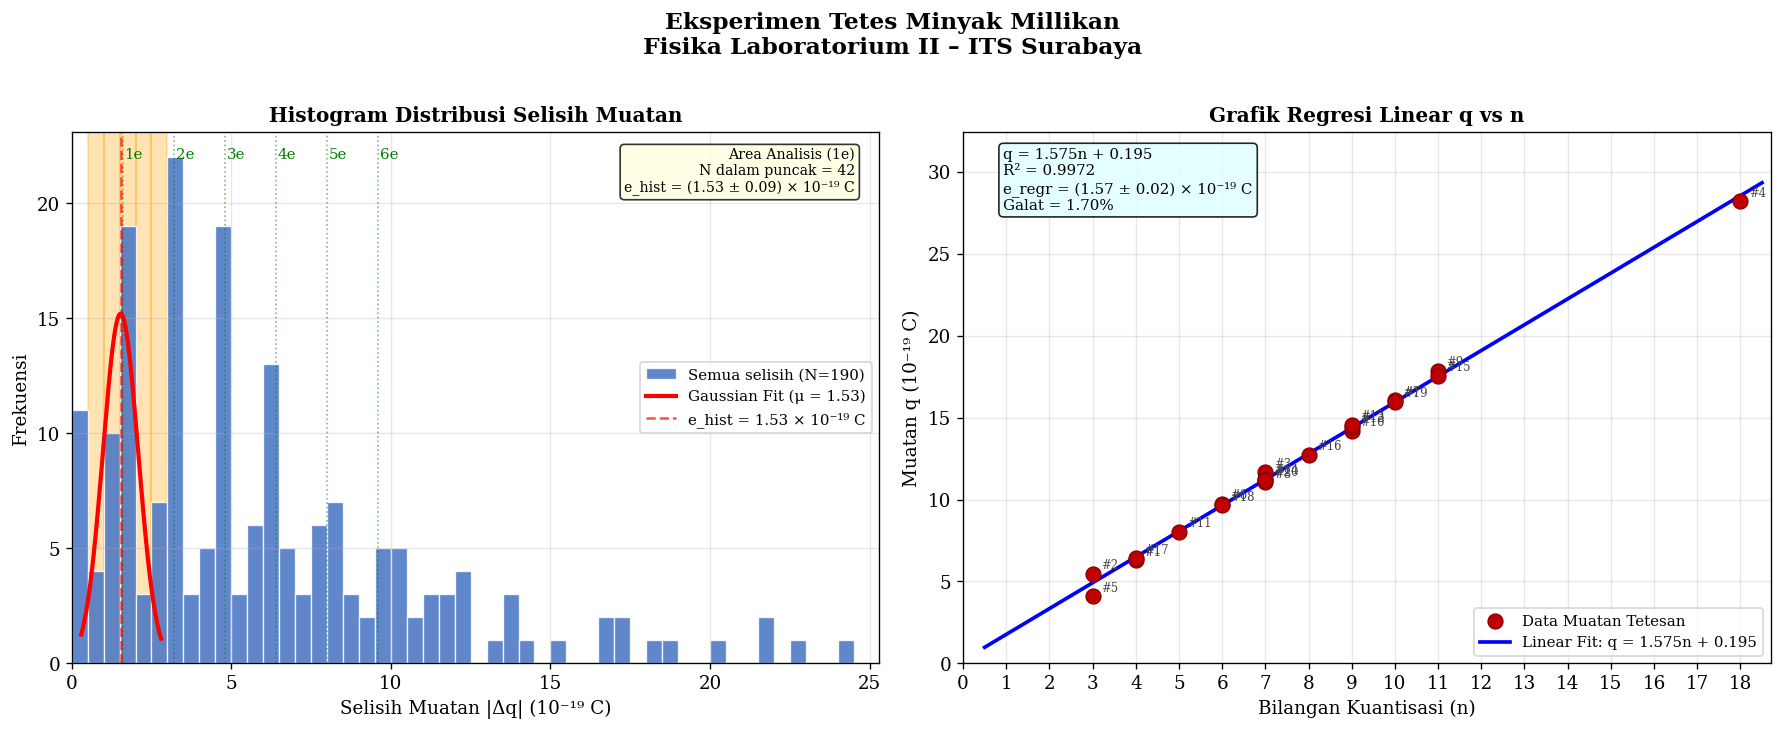


✅ Grafik tersimpan sebagai 'millikan_grafik.png'

  TABEL LENGKAP SEMUA PARAMETER TERHITUNG

Satuan: v dalam m/s, r dalam m, q dan e dalam C
 No  v_d (×10⁻⁵)  v_u (×10⁻⁵)  r (×10⁻⁷)  qr (×10⁻¹⁹)  qf (×10⁻¹⁹)  q_avg (×10⁻¹⁹)  n  e_est (×10⁻¹⁹)
  1        7.385       14.045      8.469        8.439        4.168           6.303  4           1.576
  2        7.844        5.920      8.728        5.500        5.467           5.484  3           1.828
  3       13.214        8.427     11.329       10.914       12.429          11.671  7           1.667
  4       19.589       27.263     13.794       28.830       27.577          28.204 18           1.567
  5        7.248        8.344      8.391        4.959        3.246           4.103  3           1.368
  6       13.704       10.286     11.537       11.094        8.418           9.756  6           1.626
  7       13.937       21.853     11.635       19.448       12.660          16.054 10           1.605
  8        8.244        7.220      8.948  

In [1]:
"""
=============================================================================
EKSPERIMEN TETES MINYAK MILLIKAN - ANALISIS LENGKAP
Fisika Laboratorium II | ITS Surabaya
=============================================================================
Panduan penggunaan:
1. Copy-paste seluruh kode ini ke Google Colab (File > New Notebook)
2. Jalankan setiap cell secara berurutan (Shift+Enter)
3. Atau jalankan semua sekaligus: Runtime > Run All
=============================================================================
"""

# ============================================================
# CELL 1: INSTALL & IMPORT LIBRARY
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

# Style plot
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print("=" * 60)
print("  EKSPERIMEN TETES MINYAK MILLIKAN")
print("  Fisika Laboratorium II - ITS Surabaya")
print("=" * 60)

# ============================================================
# CELL 2: INPUT DATA PENGAMATAN
# ============================================================

# Data dari hasil pengamatan (sesuai tabel)
# Format: [t_down (s), U_r (V), t_up (s), U_s (V)]
data_raw = [
    # No.  t_down    U_r    t_up     U_s
    [1,   13.541,   450,   7.12,    314],
    [2,   12.749,   457,   16.892,   262],
    [3,    7.568,   470,   11.866,   252],
    [4,    5.105,   469,    3.668,  205],
    [5,   13.796,   552,   11.985,   392],
    [6,    7.297,   522,    9.722,  393],
    [7,    7.175,   448,    4.576,  268],
    [8,   12.13,   263.2,  13.85,  138.9],
    [9,   11.72,   170.9,  13.57,   90.4],
    [10,  16.65,   121.7,  20.83,   67.7],
    [11,  12.45,   310,    17.9,   186.1],
    [12,  15.75,   107.4,  33.79,   71.4],
    [13,   6.61,   390.5,  13.75,  263.7],
    [14,  18.81,   123.4,  26.57,   69.9],
    [15,   6.83,   347.4,  10.56,  205.7],
    [16,   6.77,   334.3,  41.11,  294.4],
    [17,  12.33,   360.5,  23.23,  234.9],
    [18,  20.27,   155,    18.11,   75.1],
    [19,   9.37,   189.2,  30.27,  140.2],
    [20,  19.96,    95.8,  41.1,    66.5],
]

df = pd.DataFrame(data_raw, columns=['No', 't_down', 'U_r', 't_up', 'U_s'])

print("\n📋 DATA HASIL PENGAMATAN")
print("-" * 60)
print(f"{'No':>3} | {'t_down (s)':>10} | {'U_r (V)':>8} | {'t_up (s)':>9} | {'U_s (V)':>8}")
print("-" * 60)
for _, row in df.iterrows():
    print(f"{int(row['No']):>3} | {row['t_down']:>10.3f} | {row['U_r']:>8.1f} | {row['t_up']:>9.3f} | {row['U_s']:>8.1f}")
print("-" * 60)

# ============================================================
# CELL 3: KONSTANTA DAN PARAMETER ALAT
# ============================================================

print("\n⚙️  KONSTANTA DAN PARAMETER")
print("-" * 40)

# Konstanta fisika & parameter alat
l   = 6.00e-3     # Jarak antar pelat (m)
d   = 1.00e-3     # Jarak tempuh 1 skala grid (m)
rho_o = 875.0     # Massa jenis minyak parafin (kg/m³)
rho_f = 1.29      # Massa jenis udara @ 25°C (kg/m³)
eta   = 1.85e-5   # Viskositas udara @ 25°C (N·s/m²)
g     = 9.81      # Percepatan gravitasi (m/s²)

delta_rho = rho_o - rho_f  # Selisih massa jenis

print(f"  l   (jarak pelat)    = {l:.2e} m")
print(f"  d   (jarak grid)     = {d:.2e} m")
print(f"  ρ_o (minyak)         = {rho_o} kg/m³")
print(f"  ρ_f (udara)          = {rho_f} kg/m³")
print(f"  η   (viskositas)     = {eta:.2e} N·s/m²")
print(f"  g   (gravitasi)      = {g} m/s²")
print(f"  Δρ  = ρ_o - ρ_f      = {delta_rho:.2f} kg/m³")

# ============================================================
# CELL 4: FUNGSI PERHITUNGAN
# ============================================================

def hitung_kecepatan(t_down, t_up, d=1e-3):
    """Menghitung kecepatan terminal jatuh dan naik."""
    v_d = d / t_down   # kecepatan jatuh (m/s)
    v_u = d / t_up     # kecepatan naik (m/s)
    return v_d, v_u

def hitung_radius(v_d, eta=eta, g=g, delta_rho=delta_rho):
    """Menghitung jari-jari tetes (Persamaan Stokes)."""
    r = np.sqrt((9 * eta * v_d) / (2 * g * delta_rho))
    return r

def hitung_muatan_floating(v_d, U_s, r, eta=eta, l=l, g=g, delta_rho=delta_rho):
    """Menghitung muatan dengan metode Floating (statis)."""
    qf = (18 * np.pi * eta * l * v_d / U_s) * np.sqrt((eta * v_d) / (2 * g * delta_rho))
    return qf

def hitung_muatan_rising(v_d, v_u, U_r, r, eta=eta, l=l, g=g, delta_rho=delta_rho):
    """Menghitung muatan dengan metode Rising (dinamis)."""
    qr = (18 * np.pi * eta * l * (v_d + v_u) / U_r) * np.sqrt((eta * v_d) / (2 * g * delta_rho))
    return qr

print("\n✅ Fungsi perhitungan berhasil didefinisikan.")

# ============================================================
# CELL 5: PERHITUNGAN STEP-BY-STEP
# ============================================================

print("\n" + "=" * 70)
print("  PERHITUNGAN STEP-BY-STEP")
print("=" * 70)

resultats = []

for _, row in df.iterrows():
    no      = int(row['No'])
    t_down  = row['t_down']
    t_up    = row['t_up']
    U_r     = row['U_r']
    U_s     = row['U_s']

    print(f"\n{'─'*60}")
    print(f"  TETESAN No. {no:02d}")
    print(f"  Data: t_down={t_down} s | U_r={U_r} V | t_up={t_up} s | U_s={U_s} V")
    print(f"{'─'*60}")

    # Step 1: Kecepatan terminal
    v_d, v_u = hitung_kecepatan(t_down, t_up)
    print(f"  [1] Kecepatan Terminal:")
    print(f"      v_d = d/t_down = {d:.3e}/{t_down} = {v_d:.4e} m/s")
    print(f"      v_u = d/t_up   = {d:.3e}/{t_up} = {v_u:.4e} m/s")

    # Step 2: Jari-jari tetes
    r = hitung_radius(v_d)
    print(f"  [2] Jari-jari Tetesan:")
    print(f"      r = √(9ηv_d / 2gΔρ)")
    print(f"        = √(9×{eta:.2e}×{v_d:.4e} / 2×{g}×{delta_rho:.2f})")
    print(f"        = {r:.4e} m")

    # Step 3: Muatan
    qf = hitung_muatan_floating(v_d, U_s, r)
    qr = hitung_muatan_rising(v_d, v_u, U_r, r)
    q_avg = (qf + qr) / 2

    print(f"  [3] Muatan Listrik:")
    print(f"      qf (Floating) = {qf:.4e} C  =  {qf/1e-19:.3f} × 10⁻¹⁹ C")
    print(f"      qr (Rising)   = {qr:.4e} C  =  {qr/1e-19:.3f} × 10⁻¹⁹ C")
    print(f"      q_avg         = {q_avg:.4e} C  =  {q_avg/1e-19:.3f} × 10⁻¹⁹ C")

    resultats.append({
        'No': no,
        't_down': t_down,
        't_up': t_up,
        'U_r': U_r,
        'U_s': U_s,
        'v_d': v_d,
        'v_u': v_u,
        'r': r,
        'qf': qf,
        'qr': qr,
        'q_avg': q_avg,
    })

df_hasil = pd.DataFrame(resultats)

# ============================================================
# CELL 6: TABEL REKAPITULASI HASIL
# ============================================================

print("\n" + "=" * 70)
print("  REKAPITULASI HASIL MUATAN")
print("=" * 70)

e_ref = 1.602e-19  # Nilai referensi muatan elementer

# Penentuan bilangan kuantisasi n
e_est_init = 1.6e-19  # estimasi awal untuk pembagian n
df_hasil['n'] = np.round(df_hasil['q_avg'] / e_est_init).astype(int)
df_hasil['n'] = df_hasil['n'].clip(lower=1)
df_hasil['e_est'] = df_hasil['q_avg'] / df_hasil['n']

print(f"\n{'No':>3} | {'qr (10⁻¹⁹C)':>12} | {'qf (10⁻¹⁹C)':>12} | {'qavg (10⁻¹⁹C)':>13} | {'n':>3} | {'e_est (10⁻¹⁹C)':>14}")
print("-" * 70)
for _, row in df_hasil.iterrows():
    print(f"{int(row['No']):>3} | {row['qr']/1e-19:>12.3f} | {row['qf']/1e-19:>12.3f} | {row['q_avg']/1e-19:>13.3f} | {int(row['n']):>3} | {row['e_est']/1e-19:>14.3f}")
print("-" * 70)
print(f"\n  Rata-rata e_est = {df_hasil['e_est'].mean()/1e-19:.4f} × 10⁻¹⁹ C")
print(f"  Nilai referensi = 1.6020 × 10⁻¹⁹ C")

# ============================================================
# CELL 7: ANALISIS PAIRWISE DIFFERENCE (HISTOGRAM)
# ============================================================

print("\n" + "=" * 70)
print("  ANALISIS SELISIH BERPASANGAN (PAIRWISE DIFFERENCE)")
print("=" * 70)

q_vals = df_hasil['q_avg'].values
n_data = len(q_vals)

# Hitung selisih triangular (tidak duplikat, tidak nol)
selisih = []
for i in range(n_data):
    for j in range(i+1, n_data):
        diff = abs(q_vals[i] - q_vals[j])
        selisih.append(diff)

selisih = np.array(selisih)
selisih_19 = selisih / 1e-19  # dalam satuan 10⁻¹⁹ C

print(f"\n  Jumlah total kombinasi selisih: {len(selisih)} (n(n-1)/2 = {n_data*(n_data-1)//2})")
print(f"  Rentang selisih: {selisih_19.min():.3f} – {selisih_19.max():.3f} × 10⁻¹⁹ C")

# Filter untuk puncak pertama (1e): ambil rentang [0.3, 2.8] × 10⁻¹⁹ C
batas_bawah = 0.3e-19
batas_atas  = 2.8e-19
peak1 = selisih[(selisih >= batas_bawah) & (selisih <= batas_atas)]
peak1_19 = peak1 / 1e-19

print(f"\n  Filter puncak pertama (1e): [{batas_bawah/1e-19:.1f}, {batas_atas/1e-19:.1f}] × 10⁻¹⁹ C")
print(f"  Jumlah data dalam puncak 1e: {len(peak1)}")

# Gaussian fit pada puncak pertama
mu_peak, std_peak = norm.fit(peak1_19)
SE_peak = std_peak / np.sqrt(len(peak1))

print(f"\n  Hasil Gaussian Fit (puncak 1e):")
print(f"    μ  (e_hist) = {mu_peak:.4f} × 10⁻¹⁹ C")
print(f"    σ  (std)    = {std_peak:.4f} × 10⁻¹⁹ C")
print(f"    SE          = σ/√n = {std_peak:.4f}/√{len(peak1)} = {SE_peak:.4f} × 10⁻¹⁹ C")
print(f"\n  ┌─────────────────────────────────────────────┐")
print(f"  │  e_hist = ({mu_peak:.2f} ± {SE_peak:.2f}) × 10⁻¹⁹ C          │")
print(f"  └─────────────────────────────────────────────┘")

galat_hist = abs(mu_peak - e_ref/1e-19) / (e_ref/1e-19) * 100
print(f"  Galat relatif terhadap e_teori: {galat_hist:.2f}%")

# ============================================================
# CELL 8: REGRESI LINEAR
# ============================================================

print("\n" + "=" * 70)
print("  REGRESI LINEAR (q_avg vs n)")
print("=" * 70)

n_arr     = df_hasil['n'].values.astype(float)
q_avg_arr = df_hasil['q_avg'].values / 1e-19  # dalam 10⁻¹⁹ C

# Regresi linear dengan numpy polyfit
koef = np.polyfit(n_arr, q_avg_arr, 1)
m_regr = koef[0]   # gradien = estimasi e
c_regr = koef[1]   # intercept

# Hitung R²
q_pred = np.polyval(koef, n_arr)
SS_res = np.sum((q_avg_arr - q_pred)**2)
SS_tot = np.sum((q_avg_arr - np.mean(q_avg_arr))**2)
R2     = 1 - SS_res / SS_tot

# Hitung ralat gradien Sm
n_pts  = len(n_arr)
Sm     = np.sqrt(SS_res / (n_pts - 2)) / np.sqrt(np.sum((n_arr - n_arr.mean())**2))

print(f"\n  Hasil regresi linear  q = m·n + c:")
print(f"    Gradien (m) = {m_regr:.4f} × 10⁻¹⁹ C  → e_regr")
print(f"    Intercept c = {c_regr:.4f} × 10⁻¹⁹ C")
print(f"    R²          = {R2:.4f}")
print(f"    Ralat m (Sm)= {Sm:.4f} × 10⁻¹⁹ C")
print(f"\n  ┌─────────────────────────────────────────────┐")
print(f"  │  e_regr = ({m_regr:.2f} ± {Sm:.2f}) × 10⁻¹⁹ C         │")
print(f"  └─────────────────────────────────────────────┘")

galat_regr = abs(m_regr - e_ref/1e-19) / (e_ref/1e-19) * 100
print(f"  Galat relatif terhadap e_teori: {galat_regr:.2f}%")

# ============================================================
# CELL 9: RINGKASAN AKHIR
# ============================================================

print("\n" + "=" * 70)
print("  RINGKASAN HASIL AKHIR")
print("=" * 70)
print(f"\n  Nilai referensi literatur   : e_teori = 1.6020 × 10⁻¹⁹ C")
print(f"\n  [1] Metode Histogram (e_hist):")
print(f"      e_hist = ({mu_peak:.2f} ± {SE_peak:.2f}) × 10⁻¹⁹ C")
print(f"      Galat  = {galat_hist:.2f}%")
print(f"\n  [2] Metode Regresi Linear (e_regr):")
print(f"      e_regr = ({m_regr:.2f} ± {Sm:.2f}) × 10⁻¹⁹ C")
print(f"      Galat  = {galat_regr:.2f}%")
print(f"\n  Kesimpulan: Muatan listrik bersifat diskret/terkuantisasi (q = n·e) ✓")

# ============================================================
# CELL 10: PLOT GRAFIK HISTOGRAM
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Eksperimen Tetes Minyak Millikan\nFisika Laboratorium II – ITS Surabaya',
             fontsize=14, fontweight='bold', y=1.01)

# --- PLOT KIRI: Histogram seluruh data ---
ax1 = axes[0]

bins_all = np.arange(0, selisih_19.max() + 0.5, 0.5)
counts_all, edges_all, _ = ax1.hist(selisih_19, bins=bins_all,
                                     color='#4472C4', edgecolor='white',
                                     linewidth=0.8, alpha=0.85, label='Semua selisih (N=190)')

# Highlight area puncak 1e
for i, (left, right) in enumerate(zip(edges_all[:-1], edges_all[1:])):
    if batas_bawah/1e-19 <= left < batas_atas/1e-19:
        ax1.axvspan(left, right, alpha=0.3, color='orange', zorder=0)

# Gaussian fit pada puncak 1
x_fit = np.linspace(batas_bawah/1e-19, batas_atas/1e-19, 300)
scale  = len(peak1) * (bins_all[1]-bins_all[0])
y_fit  = norm.pdf(x_fit, mu_peak, std_peak) * scale
ax1.plot(x_fit, y_fit, 'r-', linewidth=2.5,
         label=f'Gaussian Fit (μ = {mu_peak:.2f})')

ax1.axvline(mu_peak, color='red', linestyle='--', alpha=0.7,
            label=f'e_hist = {mu_peak:.2f} × 10⁻¹⁹ C')

# Anotasi kelipatan e
e_theo = e_ref / 1e-19
for k in range(1, 7):
    ax1.axvline(k * e_theo, color='green', linestyle=':', alpha=0.5, linewidth=1)
    ax1.text(k * e_theo + 0.05, ax1.get_ylim()[1] * 0.95 if ax1.get_ylim()[1] > 0 else 5,
             f'{k}e', color='green', fontsize=9, ha='left')

ax1.set_xlabel('Selisih Muatan |Δq| (10⁻¹⁹ C)', fontsize=11)
ax1.set_ylabel('Frekuensi', fontsize=11)
ax1.set_title('Histogram Distribusi Selisih Muatan', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_xlim(0, selisih_19.max() * 1.05)

# Tambahkan teks kotak hasil
textstr = (f'Area Analisis (1e)\n'
           f'N dalam puncak = {len(peak1)}\n'
           f'e_hist = ({mu_peak:.2f} ± {SE_peak:.2f}) × 10⁻¹⁹ C')
props = dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
ax1.text(0.97, 0.97, textstr, transform=ax1.transAxes, fontsize=8.5,
         verticalalignment='top', horizontalalignment='right', bbox=props)

# --- PLOT KANAN: Regresi Linear ---
ax2 = axes[1]

n_plot  = np.linspace(0.5, n_arr.max() + 0.5, 200)
q_line  = np.polyval(koef, n_plot)

ax2.scatter(n_arr, q_avg_arr, color='#C00000', s=80, zorder=5,
            label='Data Muatan Tetesan', edgecolors='darkred', linewidth=0.8)
ax2.plot(n_plot, q_line, 'b-', linewidth=2.2,
         label=f'Linear Fit: q = {m_regr:.3f}n + {c_regr:.3f}')

ax2.set_xlabel('Bilangan Kuantisasi (n)', fontsize=11)
ax2.set_ylabel('Muatan q (10⁻¹⁹ C)', fontsize=11)
ax2.set_title('Grafik Regresi Linear q vs n', fontsize=12, fontweight='bold')
ax2.set_xticks(range(0, int(n_arr.max()) + 2))
ax2.set_xlim(0, n_arr.max() + 0.7)
ax2.set_ylim(0, q_avg_arr.max() * 1.15)

# Label setiap titik
for _, row in df_hasil.iterrows():
    ax2.annotate(f"#{int(row['No'])}",
                 (row['n'], row['q_avg']/1e-19),
                 textcoords="offset points", xytext=(5, 3),
                 fontsize=7, color='#444')

textstr2 = (f'q = {m_regr:.3f}n + {c_regr:.3f}\n'
            f'R² = {R2:.4f}\n'
            f'e_regr = ({m_regr:.2f} ± {Sm:.2f}) × 10⁻¹⁹ C\n'
            f'Galat = {galat_regr:.2f}%')
props2 = dict(boxstyle='round', facecolor='lightcyan', alpha=0.85)
ax2.text(0.05, 0.97, textstr2, transform=ax2.transAxes, fontsize=9,
         verticalalignment='top', bbox=props2)

ax2.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('millikan_grafik.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Grafik tersimpan sebagai 'millikan_grafik.png'")

# ============================================================
# CELL 11: TABEL RINGKASAN SEMUA HASIL (PANDAS DISPLAY)
# ============================================================

print("\n" + "=" * 70)
print("  TABEL LENGKAP SEMUA PARAMETER TERHITUNG")
print("=" * 70)

df_display = df_hasil[['No','v_d','v_u','r','qr','qf','q_avg','n','e_est']].copy()
df_display['v_d']   = df_display['v_d'] * 1e5       # × 10⁻⁵ m/s
df_display['v_u']   = df_display['v_u'] * 1e5
df_display['r']     = df_display['r'] * 1e7          # × 10⁻⁷ m
df_display['qr']    = df_display['qr'] / 1e-19       # × 10⁻¹⁹ C
df_display['qf']    = df_display['qf'] / 1e-19
df_display['q_avg'] = df_display['q_avg'] / 1e-19
df_display['e_est'] = df_display['e_est'] / 1e-19

df_display.columns = [
    'No', 'v_d (×10⁻⁵)', 'v_u (×10⁻⁵)', 'r (×10⁻⁷)',
    'qr (×10⁻¹⁹)', 'qf (×10⁻¹⁹)', 'q_avg (×10⁻¹⁹)', 'n', 'e_est (×10⁻¹⁹)'
]

pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
print("\nSatuan: v dalam m/s, r dalam m, q dan e dalam C")
print(df_display.to_string(index=False))

print("\n" + "=" * 70)
print("  SELESAI - Eksperimen Tetes Minyak Millikan")
print(f"  e_hist = ({mu_peak:.2f} ± {SE_peak:.2f}) × 10⁻¹⁹ C  |  Galat: {galat_hist:.2f}%")
print(f"  e_regr = ({m_regr:.2f} ± {Sm:.2f}) × 10⁻¹⁹ C  |  Galat: {galat_regr:.2f}%")
print("=" * 70)

=== HASIL MUATAN (C) ===
              qf            qr          qavg
0   4.167660e-19  8.438802e-19  6.303231e-19
1   5.467422e-19  5.500493e-19  5.483957e-19
2   1.242870e-18  1.091263e-18  1.167067e-18
3   2.757723e-18  2.883038e-18  2.820380e-18
4   3.246252e-19  4.957857e-19  4.102055e-19
5   8.417614e-19  1.109403e-18  9.755824e-19
6   1.265990e-18  1.944805e-18  1.605398e-18
7   1.111232e-18  1.100045e-18  1.105638e-18
8   1.797787e-18  1.772285e-18  1.785036e-18
9   1.417712e-18  1.419046e-18  1.418379e-18
10  7.976230e-19  8.118728e-19  8.047479e-19
11  1.461097e-18  1.424101e-18  1.442599e-18
12  1.455076e-18  1.454956e-18  1.455016e-18
13  1.143504e-18  1.106299e-18  1.124902e-18
14  1.775958e-18  1.731701e-18  1.753829e-18
15  1.257411e-18  1.289690e-18  1.273551e-18
16  6.411659e-19  6.395297e-19  6.403478e-19
17  9.514315e-19  9.769498e-19  9.641906e-19
18  1.621589e-18  1.573580e-18  1.597584e-18
19  1.099602e-18  1.133983e-18  1.116793e-18

Estimasi e (histogram) = 1.64

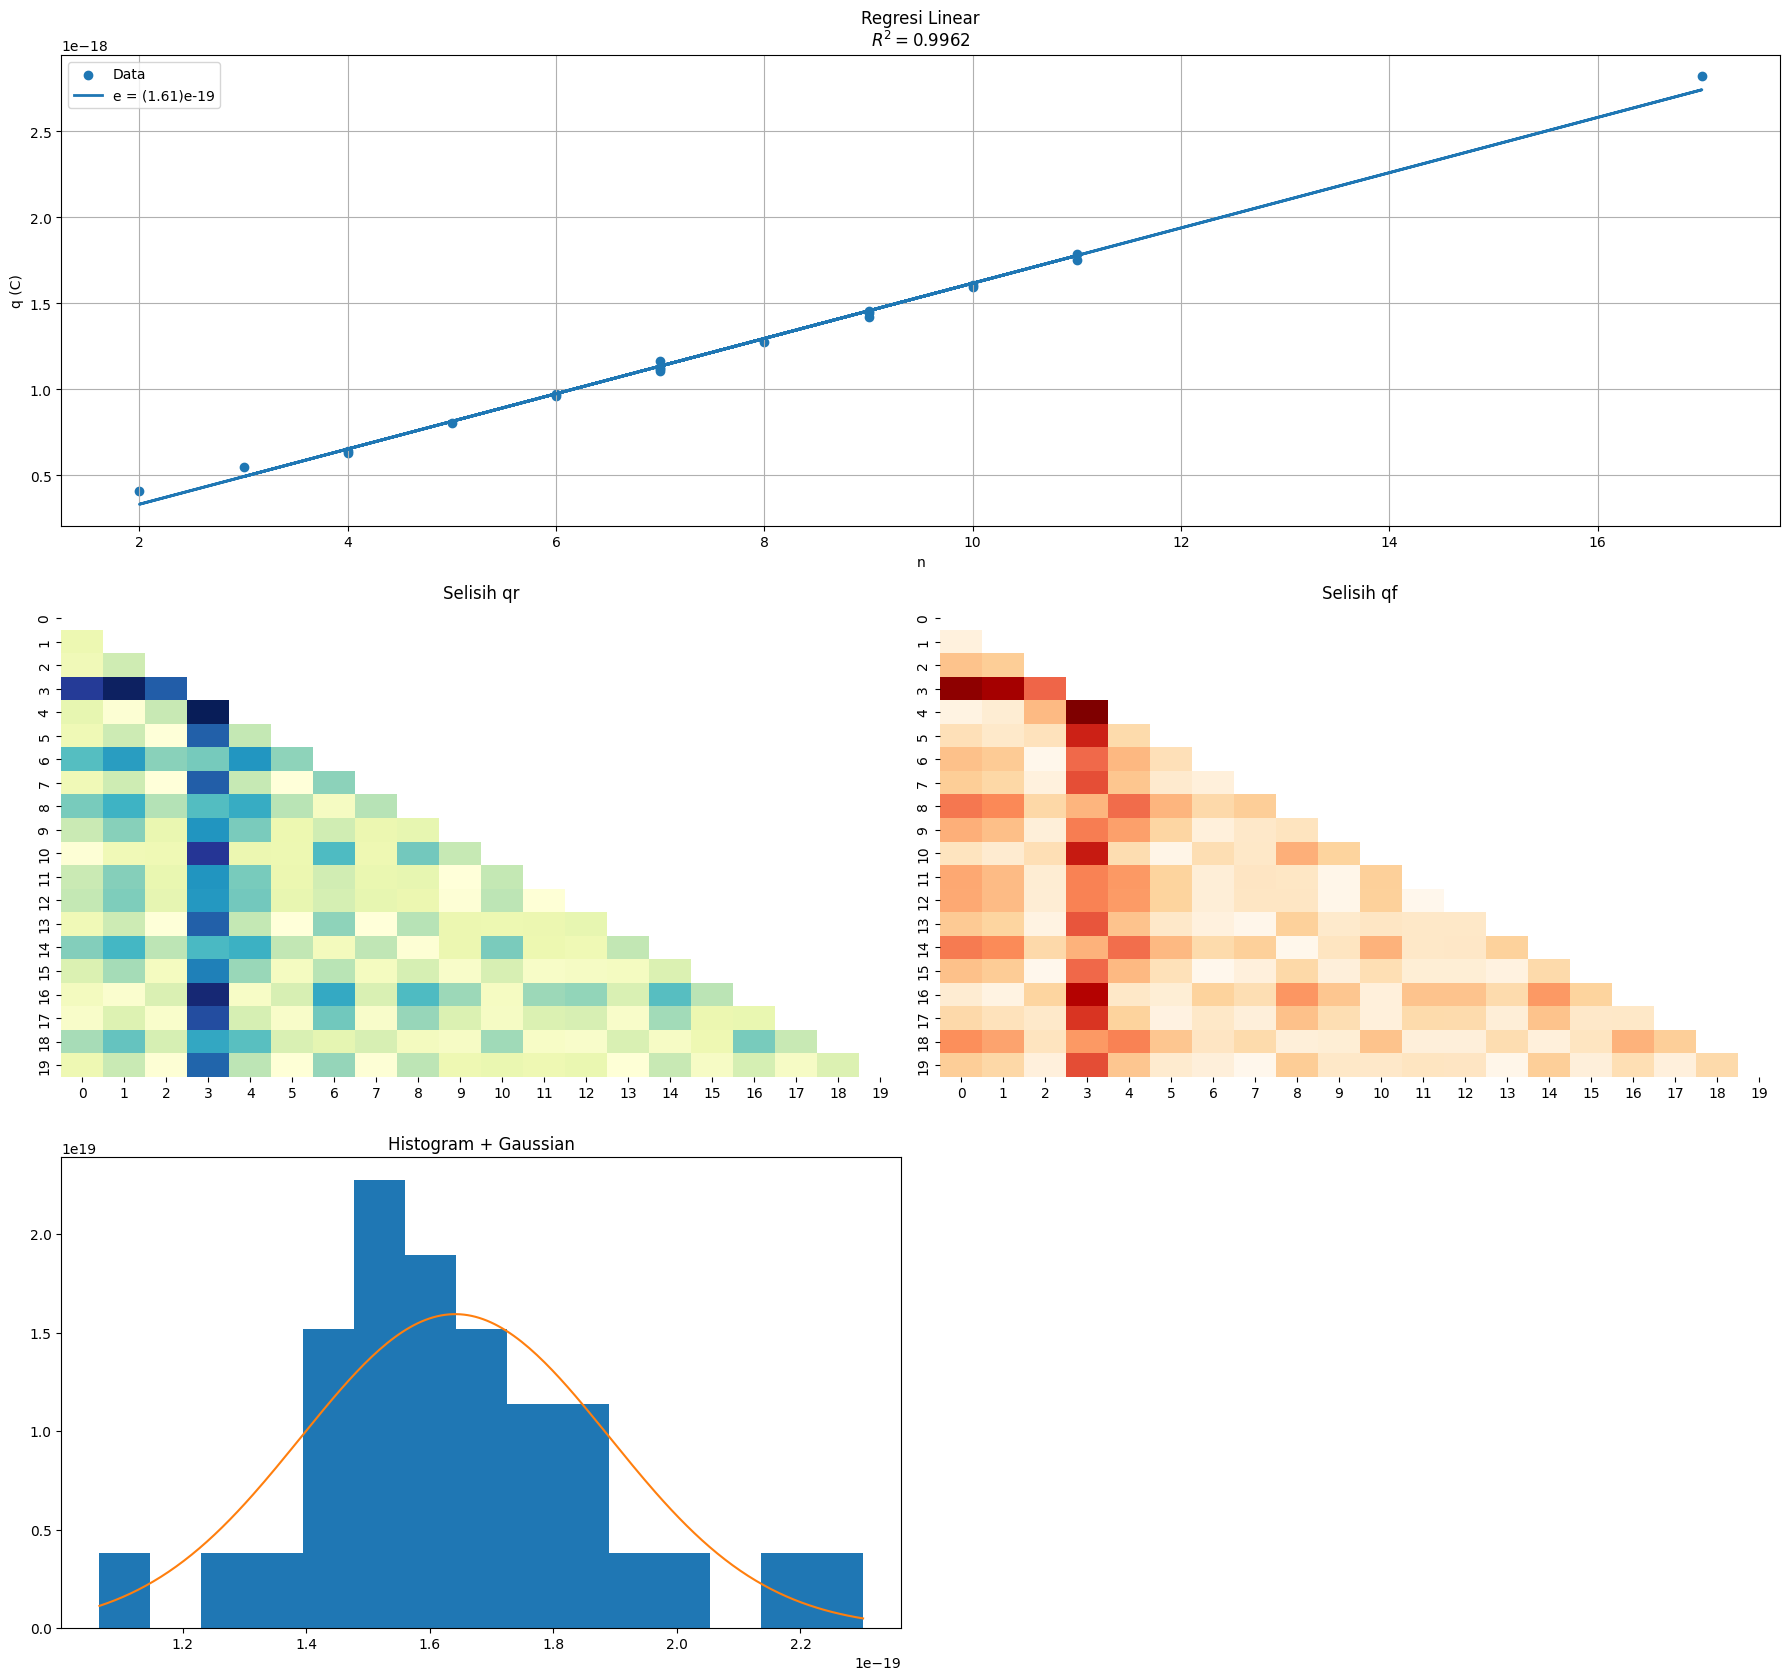

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.linear_model import LinearRegression

# ================================
# DATA
# ================================
data = {
    'td': [13.541,12.749,7.568,5.105,13.796,7.297,7.175,12.13,11.72,16.65,12.45,15.75,6.61,18.81,6.83,6.77,12.33,20.27,9.37,19.96],
    'tu': [7.12,16.89,11.87,3.668,11.99,9.722,4.576,13.85,13.57,20.83,17.9,33.79,13.75,26.57,10.56,41.11,23.23,18.11,30.27,41.1],
    'Us': [314,262,252,205,392,393,268,138.9,90.4,67.7,186.1,71.4,263.7,69.9,205.7,294.4,234.9,75.1,140.2,66.5],
    'Ur': [450,457,470,469,552,522,448,263.2,170.9,121.7,310,107.4,390.5,123.4,347.4,334.3,360.5,155,189.2,95.8]
}

df = pd.DataFrame(data)

# ================================
# KONSTANTA
# ================================
d = 1e-3
l = 6e-3
eta = 1.85e-5
rho_o = 875
rho_f = 1.29
g = 9.81

# ================================
# KECEPATAN
# ================================
df['vd'] = d / df['td']
df['vu'] = d / df['tu']

# ================================
# JARI-JARI
# ================================
df['r'] = np.sqrt((9 * eta * df['vd']) / (2 * g * (rho_o - rho_f)))

# ================================
# MUATAN
# ================================
df['qf'] = (18 * np.pi * eta * l * df['vd'] / df['Us']) * np.sqrt((eta * df['vd']) / (2 * g * (rho_o - rho_f)))
df['qr'] = (18 * np.pi * eta * l * (df['vd'] + df['vu']) / df['Ur']) * np.sqrt((eta * df['vd']) / (2 * g * (rho_o - rho_f)))
df['qavg'] = (df['qf'] + df['qr']) / 2

print("=== HASIL MUATAN (C) ===")
print(df[['qf','qr','qavg']])

# ================================
# PAIRWISE DIFFERENCE → cari e
# ================================
diffs = []
vals = df['qavg'].values

for i in range(len(vals)):
    for j in range(i):
        diffs.append(abs(vals[i] - vals[j]))

diffs = np.array(diffs)

# FILTER puncak pertama
filtered = diffs[(diffs > 1e-19) & (diffs < 2.5e-19)]

# Gaussian fit
mu, std = stats.norm.fit(filtered)

print("\nEstimasi e (histogram) =", mu)

# ================================
# BUAT n & e_est
# ================================
df['n'] = np.round(df['qavg'] / mu)

# hindari n=0
df = df[df['n'] != 0]

df['e_est'] = df['qavg'] / df['n']

# ================================
# REGRESI LINEAR
# ================================
X_reg = df['n'].values.reshape(-1, 1)
y_reg = df['qavg'].values

model = LinearRegression().fit(X_reg, y_reg)
y_pred = model.predict(X_reg)
r_sq = model.score(X_reg, y_reg)

# ================================
# OUTPUT
# ================================
print("\n--- HASIL PERHITUNGAN ---")
print(df[['qf', 'qr', 'qavg', 'n', 'e_est']].to_string())
print(f"\nGradien (e estimasi): {model.coef_[0]:.4e} C")
print(f"R-squared: {r_sq:.4f}")

# ================================
# VISUALISASI
# ================================
fig = plt.figure(figsize=(18, 22))

# A. Regresi Linear
ax1 = plt.subplot(4, 1, 1)
ax1.scatter(df['n'], df['qavg'], label='Data')
ax1.plot(df['n'], y_pred, linewidth=2,
         label=f'e = ({model.coef_[0]/1e-19:.2f})e-19')
ax1.set_title(f'Regresi Linear\n$R^2 = {r_sq:.4f}$')
ax1.set_xlabel('n')
ax1.set_ylabel('q (C)')
ax1.grid()
ax1.legend()

# B. Matriks Rising
ax2 = plt.subplot(4, 2, 3)
mat_r = np.abs(np.subtract.outer(df['qr'].values, df['qr'].values))
mask = np.triu(np.ones_like(mat_r, dtype=bool))
sns.heatmap(mat_r, mask=mask, cmap='YlGnBu', ax=ax2, cbar=False)
ax2.set_title('Selisih qr')

# C. Matriks Floating
ax3 = plt.subplot(4, 2, 4)
mat_f = np.abs(np.subtract.outer(df['qf'].values, df['qf'].values))
sns.heatmap(mat_f, mask=mask, cmap='OrRd', ax=ax3, cbar=False)
ax3.set_title('Selisih qf')

# D. Histogram Gaussian
ax4 = plt.subplot(4, 2, 5)
ax4.hist(filtered, bins=15, density=True)
x = np.linspace(min(filtered), max(filtered), 200)
ax4.plot(x, stats.norm.pdf(x, mu, std))
ax4.set_title('Histogram + Gaussian')

plt.tight_layout()
plt.show()

    No         qr         qf      q_avg
0    1   8.438802   4.167660   6.303231
1    2   5.500493   5.467422   5.483957
2    3  10.912629  12.428704  11.670666
3    4  28.830383  27.577226  28.203805
4    5   4.957857   3.246252   4.102055
5    6  11.094033   8.417614   9.755824
6    7  19.448047  12.659904  16.053976
7    8  11.000448  11.112317  11.056382
8    9  17.722850  17.977869  17.850360
9   10  14.190459  14.177121  14.183790
10  11   8.118728   7.976230   8.047479
11  12  14.241009  14.610969  14.425989
12  13  14.549562  14.550762  14.550162
13  14  11.062993  11.435040  11.249017
14  15  17.317008  17.759581  17.538295
15  16  12.896901  12.574110  12.735505
16  17   6.395297   6.411659   6.403478
17  18   9.769498   9.514315   9.641906
18  19  15.735798  16.215885  15.975842
19  20  11.339835  10.996022  11.167929


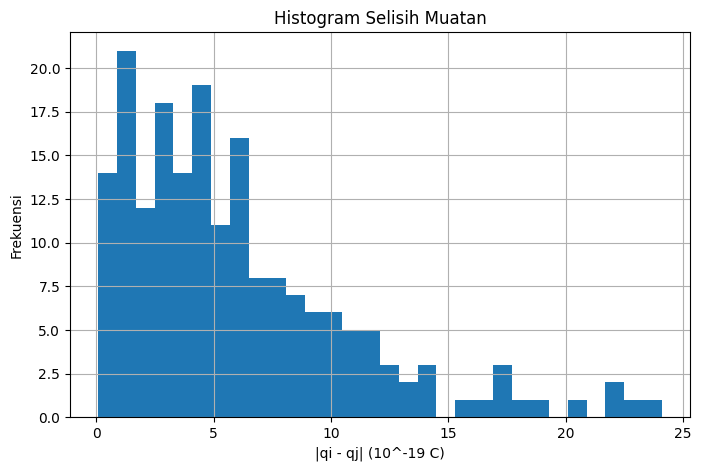

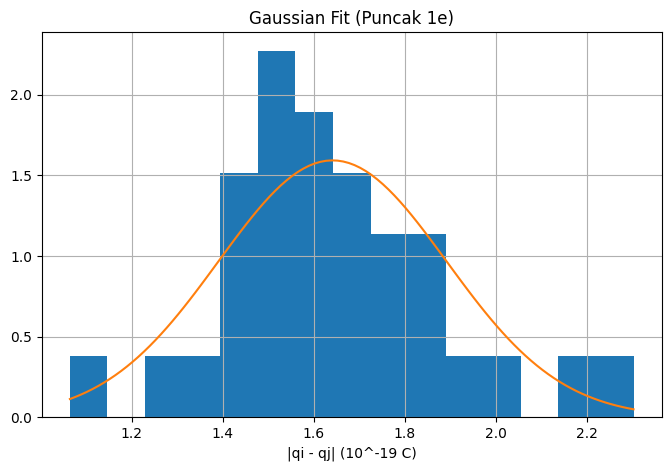

Estimasi e (Histogram) = 1.6409777558826364 x10^-19 C
Standar deviasi = 0.2504029137325304


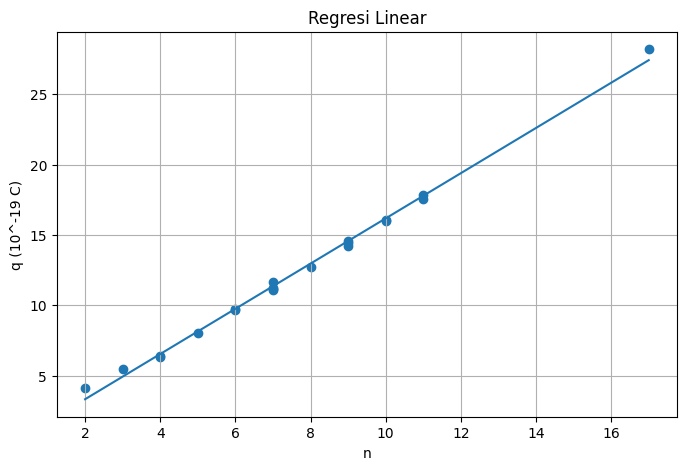

e (Regresi) = 1.607059767219789 x10^-19 C
Intercept = 0.10632810192107416


In [ ]:
# ================================
# IMPORT LIBRARY
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from itertools import combinations

# ================================
# DATA
# ================================
d = 1e-3

td = np.array([13.541,12.749,7.568,5.105,13.796,7.297,7.175,12.13,11.72,16.65,12.45,15.75,6.61,18.81,6.83,6.77,12.33,20.27,9.37,19.96])

tu = np.array([7.12,16.89,11.87,3.668,11.99,9.722,4.576,13.85,13.57,20.83,17.9,33.79,13.75,26.57,10.56,41.11,23.23,18.11,30.27,41.1])

Ur = np.array([450,457,470,469,552,522,448,263.2,170.9,121.7,310,107.4,390.5,123.4,347.4,334.3,360.5,155,189.2,95.8])

Us = np.array([314,262,252,205,392,393,268,138.9,90.4,67.7,186.1,71.4,263.7,69.9,205.7,294.4,234.9,75.1,140.2,66.5])


# ================================
# KONSTANTA
# ================================
eta = 1.85e-5
g = 9.81
l = 6e-3
rho_diff = 873.71

# ================================
# KECEPATAN
# ================================
vd = d / td
vu = d / tu

# ================================
# HITUNG MUATAN (FIX)
# ================================
qr_list = []
qf_list = []

for i in range(len(td)):

    v_sum = vd[i] + vu[i]


    r = np.sqrt((9 * eta * vd[i]) / (2 * g * rho_diff))


    qr = (6 * np.pi * eta * r * l * v_sum) / Ur[i]
    qf = (6 * np.pi * eta * r * l * vd[i]) / Us[i]

    qr_list.append(qr)
    qf_list.append(qf)

qr = np.array(qr_list)
qf = np.array(qf_list)

# ================================
# RATA-RATA
# ================================
q_avg = (qr + qf) / 2

# ================================
# KONVERSI
# ================================
qr_disp = qr * 1e19
qf_disp = qf * 1e19
qavg_disp = q_avg * 1e19

# ================================
# OUTPUT
# ================================
df = pd.DataFrame({
    'No': np.arange(1,21),
    'qr': qr_disp,
    'qf': qf_disp,
    'q_avg': qavg_disp
})

print(df)

diff = []

for i, j in combinations(q_avg, 2):
    diff.append(abs(i - j))

diff = np.array(diff)

# ================================
# 5. HISTOGRAM
# ================================
plt.figure(figsize=(8,5))
plt.hist(diff*1e19, bins=30)
plt.xlabel('|qi - qj| (10^-19 C)')
plt.ylabel('Frekuensi')
plt.title('Histogram Selisih Muatan')
plt.grid()
plt.show()

# ================================
# 6. FILTER PUNCAK PERTAMA (1e)
# ================================
# batas bisa kamu adjust
lower = 1.0   # x10^-19
upper = 2.5

filtered = diff[(diff*1e19 > lower) & (diff*1e19 < upper)]

# ================================
# 7. GAUSSIAN FIT
# ================================
mu, std = norm.fit(filtered*1e19)

x = np.linspace(min(filtered*1e19), max(filtered*1e19), 100)

plt.figure(figsize=(8,5))
plt.hist(filtered*1e19, bins=15, density=True)
plt.plot(x, norm.pdf(x, mu, std))
plt.xlabel('|qi - qj| (10^-19 C)')
plt.title('Gaussian Fit (Puncak 1e)')
plt.grid()
plt.show()

print("Estimasi e (Histogram) =", mu, "x10^-19 C")
print("Standar deviasi =", std)

# ================================
# 8. HITUNG n (PEMBULATAN)
# ================================
e_est = mu * 1e-19

n = np.round(q_avg / e_est)

# ================================
# 9. REGRESI LINEAR
# ================================
coeff = np.polyfit(n, q_avg*1e19, 1)
m, c = coeff

x_line = np.linspace(min(n), max(n), 100)
y_line = m*x_line + c

plt.figure(figsize=(8,5))
plt.scatter(n, q_avg*1e19)
plt.plot(x_line, y_line)
plt.xlabel('n')
plt.ylabel('q (10^-19 C)')
plt.title('Regresi Linear')
plt.grid()
plt.show()

print("e (Regresi) =", m, "x10^-19 C")
print("Intercept =", c)

In [ ]:
import pandas as pd
import numpy as np

# Konstanta
eta = 1.81e-5  # Ns/m^2
rho_minyak = 875.3  # kg/m^3
rho_udara = 1.29    # kg/m^3
g = 9.8             # m/s^2
e = 1.602e-19       # C (muatan elementer)
d = 0.006           # m (jarak antar pelat, misal 6 mm)
pi = np.pi

# Data harus dictionary dengan tanda {}
data =  {
    'U_F': [322, 292, 368, 323, 345, 369, 392, 357, 304, 382, 256.00, 455.00, 354.00, 353.00, 474.00, 504.00, 416.00, 322.00, 388.00, 453.00, 237.00, 475.00, 331.00, 291.00, 428.00, 385.00, 458.00, 460.00, 426.00, 445.00
],
    'U_U': [566, 533, 595, 594, 594, 578, 568, 593, 553, 569, 452.00, 587.00, 578.00, 584.00, 583.00, 587.00, 582.00, 583.00, 583.00, 585.00, 586.00, 585.00, 587.00, 587.00, 587.00, 587.00, 587.00, 587.00, 587.00, 587.00
],
    'v_d': [8.308, 5.783, 13.282, 15.878, 11.541, 9.895, 12.181, 8.786, 15.521, 7.694, 11.164, 13.467, 11.476, 12.620, 11.143, 11.643, 12.902, 16.617, 12.216, 13.583, 10.766, 15.373, 6.234, 13.088, 11.919, 14.402, 15.321, 11.611, 14.892, 10.717

],
    'v_u': [66.892, 3.287, 8.062, 12.111, 5.656, 9.516, 8.256, 6.590, 11.298, 8.567, 6.055, 6.724, 7.809, 9.747, 9.842, 10.409, 7.072, 10.934, 9.843, 7.721, 4.391, 9.317, 3.878, 9.892, 7.369, 6.560, 9.008, 9.109, 10.269, 8.356

]
}

df = pd.DataFrame(data)

# Koreksi konversi kecepatan, dari 10^-4 m/s ke m/s berarti kali 1e-4
df['v_d'] = df['v_d'] * 1e-4
df['v_u'] = df['v_u'] * 1e-4

# Hitung rata-rata tegangan
df['U_avg'] = (df['U_F'] + df['U_U']) / 2

# Gunakan U_avg untuk medan listrik
df['E'] = df['U_avg'] / d

# Hitung muatan q_rf sesuai rumus
df['q_rf'] = (18 * pi * eta * (df['v_u'] + df['v_d']) / df['E']) * \
    np.sqrt((eta * df['v_d']) / (2 * g * (rho_minyak - rho_udara)))

# Hitung n dan muatan elektron hasil eksperimen
df['n'] = np.round(df['q_rf'] / e).astype(int)
df['e_exp'] = df['q_rf'] / df['n']

# Hitung error relatif epsilon_e dalam persen
df['epsilon_e'] = np.abs((df['e_exp'] - e) / e) * 100

# Hitung standar deviasi S dari q_rf
S = np.std(df['q_rf'])

# Susun tabel akhir
result_table = pd.DataFrame({
    'q_rf x 10^-19 (C)': df['q_rf'] / 1e-19,
    'n': df['n'],
    'e x 10^-19 (C)': df['e_exp'] / 1e-19,
    'ε_e (%)': df['epsilon_e']
})

print("Tabel Hasil Pengukuran dan Perhitungan Muatan Tetes Minyak Millikan (q_rf)")
print(result_table.to_string(index=False, float_format='%.4f'))
print(f"\nStandar deviasi S dari q_rf: {S:.4e} C")


Tabel Hasil Pengukuran dan Perhitungan Muatan Tetes Minyak Millikan (q_rf)
 q_rf x 10^-19 (C)   n  e x 10^-19 (C)  ε_e (%)
          974.5146 608          1.6028   0.0512
          105.5517  66          1.5993   0.1705
          322.4902 201          1.6044   0.1516
          485.5693 303          1.6025   0.0336
          248.3957 155          1.6026   0.0345
          257.4193 161          1.5989   0.1949
          296.6352 185          1.6034   0.0895
          191.5361 120          1.5961   0.3662
          492.2173 307          1.6033   0.0820
          189.3556 118          1.6047   0.1690
          324.4291 203          1.5982   0.2389
          283.8970 177          1.6039   0.1210
          279.8558 175          1.5992   0.1763
          338.5580 211          1.6045   0.1586
          264.5881 165          1.6036   0.0976
          275.3537 172          1.6009   0.0691
          287.0108 179          1.6034   0.0882
          495.4506 309          1.6034   0.0874
          317

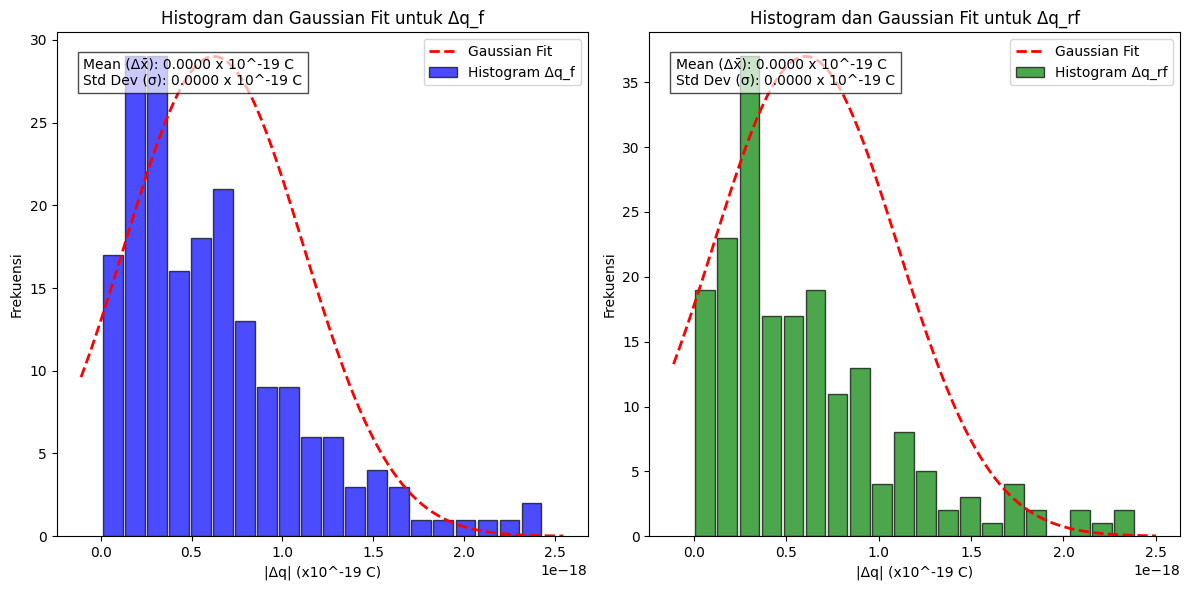

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm # Import fungsi norm untuk distribusi normal

q_f = [ 4.167660e-19, 5.467422e-19, 1.242870e-18, 2.757723e-18, 3.246252e-19, 8.417614e-19, 1.265990e-18, 1.111232e-18, 1.797787e-18, 1.417712e-18, 7.976230e-19, 1.461097e-18, 1.455076e-18, 1.143504e-18, 1.775958e-18, 1.257411e-18, 6.411659e-19, 9.514315e-19, 1.621589e-18, 1.099602e-18
]

# Data q_rf (falling and rising method) in units of 10^-19 C
q_rf = [ 8.438802e-19, 5.500493e-19, 1.091263e-18, 2.883038e-18, 4.957857e-19, 1.109403e-18, 1.944805e-18, 1.100045e-18, 1.772285e-18, 1.419046e-18, 8.118728e-19, 1.424101e-18, 1.454956e-18, 1.106299e-18, 1.731701e-18, 1.289690e-18, 6.395297e-19, 9.769498e-19, 1.573580e-18, 1.133983e-18
]

# Function to calculate mean manually
def mean(data):
    total = 0
    for x in data:
        total += x
    return total / len(data)

# Function to calculate standard deviation manually (sample standard deviation)
def std_dev(data):
    m = mean(data)
    variance_sum = 0
    for x in data:
        variance_sum += (x - m) ** 2
    if len(data) <= 1: # Handle case with 0 or 1 data point
        return 0
    variance = variance_sum / (len(data) - 1)
    return variance ** 0.5

# Calculate all absolute differences for q_f
selisih_qf = []
for i in range(len(q_f)):
    for j in range(i+1, len(q_f)):
        selisih_qf.append(abs(q_f[i] - q_f[j]))

# Calculate all absolute differences for q_rf
selisih_qrf = []
for i in range(len(q_rf)):
    for j in range(i+1, len(q_rf)):
        selisih_qrf.append(abs(q_rf[i] - q_rf[j]))

# Calculate mean and std dev for the differences
mean_qf = mean(selisih_qf)
std_qf = std_dev(selisih_qf)

mean_qrf = mean(selisih_qrf)
std_qrf = std_dev(selisih_qrf)

# Function to create histogram data manually
def create_histogram(data, bins):
    if not data: # Handle empty data list
        return [], []
    min_val = min(data)
    max_val = max(data)
    if min_val == max_val: # Handle case where all values are the same
        return [len(data)], [min_val, max_val] # Single bin
    bin_width = (max_val - min_val) / bins
    counts = [0] * bins
    for d in data:
        # Find bin index
        idx = int((d - min_val) / bin_width)
        if idx == bins:  # edge case for max value
            idx -= 1
        counts[idx] += 1
    bin_edges = [min_val + i * bin_width for i in range(bins + 1)]
    return counts, bin_edges

# Create histograms
bins = 20
counts_qf, bins_qf = create_histogram(selisih_qf, bins)
counts_qrf, bins_qrf = create_histogram(selisih_qrf, bins)

# Plotting
plt.figure(figsize=(12, 6))

# Plot for q_f
plt.subplot(1, 2, 1)
if bins_qf: # Check if bins were created (data is not empty)
    bin_centers_qf = [(bins_qf[i] + bins_qf[i+1]) / 2 for i in range(len(bins_qf)-1)]
    plt.bar(bin_centers_qf, counts_qf, width=(bins_qf[1]-bins_qf[0])*0.9, color='blue', edgecolor='black', alpha=0.7, label='Histogram Δq_f')

    # Plot Gaussian fit for q_f differences
    xmin_qf, xmax_qf = plt.xlim()
    x_qf = np.linspace(xmin_qf, xmax_qf, 100)
    p_qf = norm.pdf(x_qf, mean_qf, std_qf)
    # Scale the PDF to match the histogram height
    max_hist_qf = max(counts_qf) if counts_qf else 0
    max_pdf_qf = norm.pdf(mean_qf, mean_qf, std_qf) if std_qf > 0 else 0
    if max_pdf_qf > 0:
        scale_qf = max_hist_qf / max_pdf_qf
        plt.plot(x_qf, p_qf * scale_qf, 'r--', linewidth=2, label='Gaussian Fit')

plt.title('Histogram dan Gaussian Fit untuk Δq_f')
plt.xlabel('|Δq| (x10^-19 C)')
plt.ylabel('Frekuensi')
plt.text(0.05, 0.95, f'Mean (Δx̄): {mean_qf:.4f} x 10^-19 C\nStd Dev (σ): {std_qf:.4f} x 10^-19 C',
         transform=plt.gca().transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))
plt.legend() # Show legend to differentiate histogram and fit

# Plot for q_rf
plt.subplot(1, 2, 2)
if bins_qrf: # Check if bins were created
    bin_centers_qrf = [(bins_qrf[i] + bins_qrf[i+1]) / 2 for i in range(len(bins_qrf)-1)]
    plt.bar(bin_centers_qrf, counts_qrf, width=(bins_qrf[1]-bins_qrf[0])*0.9, color='green', edgecolor='black', alpha=0.7, label='Histogram Δq_rf')

    # Plot Gaussian fit for q_rf differences
    xmin_qrf, xmax_qrf = plt.xlim()
    x_qrf = np.linspace(xmin_qrf, xmax_qrf, 100)
    p_qrf = norm.pdf(x_qrf, mean_qrf, std_qrf)
    # Scale the PDF to match the histogram height
    max_hist_qrf = max(counts_qrf) if counts_qrf else 0
    max_pdf_qrf = norm.pdf(mean_qrf, mean_qrf, std_qrf) if std_qrf > 0 else 0
    if max_pdf_qrf > 0:
        scale_qrf = max_hist_qrf / max_pdf_qrf
        plt.plot(x_qrf, p_qrf * scale_qrf, 'r--', linewidth=2, label='Gaussian Fit')


plt.title('Histogram dan Gaussian Fit untuk Δq_rf')
plt.xlabel('|Δq| (x10^-19 C)')
plt.ylabel('Frekuensi')
plt.text(0.05, 0.95, f'Mean (Δx̄): {mean_qrf:.4f} x 10^-19 C\nStd Dev (σ): {std_qrf:.4f} x 10^-19 C',
         transform=plt.gca().transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))
plt.legend() # Show legend

plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.0 MB/s eta 0:00:00


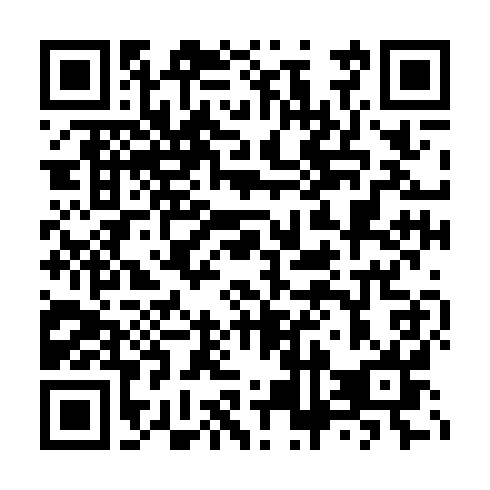

In [ ]:
# Install library qrcode
!pip install qrcode[pil]

# Import library
import qrcode
from IPython.display import Image, display

# Ganti URL di bawah ini dengan link Google Colab yang kamu inginkan
link = "https://colab.research.google.com/drive/1B-EavjBq8OELuHyftAnpn_wFh6hMPCyY#scrollTo=j6NolJLZgNOm"

# Buat QR code
qr = qrcode.make(link)

# Tampilkan QR code
qr.save("qrcode_colab.png")
display(Image(filename="qrcode_colab.png"))
